In [20]:
import os, random, re, math, json, collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, Dense,
    Dropout, SpatialDropout1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))

TensorFlow: 2.20.0
GPU available: False


In [ ]:
RAW_CSV      = 'big_waste_dataset.csv'   
SAMPLES_PER_CLASS = 200                  
TRAIN_SPLIT  = 0.8
VAL_SPLIT    = 0.1   
# TEST_SPLIT = 0.1

df_raw = pd.read_csv(RAW_CSV)
print(f'Raw rows: {len(df_raw):,}')
print(df_raw.head(3))

Raw rows: 2,336
                                                text
0  Waste managementorwaste disposalincludes the p...
1  Waste can either be solid, liquid, or gases an...
2  In some cases, waste can pose a threat to huma...


In [ ]:
# Keyword-based labeling
KEYWORDS = {
    'glass':   ['glass', 'bottle', 'jar', 'glazing', 'silica',
                'cullet', 'windshield', 'crystal', 'lens'],
    'paper':   ['paper', 'cardboard', 'newspaper', 'carton', 'pulp',
                'cellulose', 'tissue', 'magazine', 'kraft', 'corrugated'],
    'metal':   ['metal', 'aluminum', 'aluminium', 'steel', 'iron',
                'copper', 'tin', 'can', 'scrap', 'brass', 'ferrous'],
    'plastic': ['plastic', 'polymer', 'polystyrene', 'polyethylene',
                'pvc', 'nylon', 'resin', 'polypropylene', 'polyester'],
}

def label_text(text):
    t = text.lower()
    scores = {cat: sum(t.count(kw) for kw in kws) for cat, kws in KEYWORDS.items()}
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else None

df_raw['label'] = df_raw['text'].apply(label_text)
df_labeled = df_raw.dropna(subset=['label']).reset_index(drop=True)

print('Labeled rows:', len(df_labeled))
print()
print('Distribution before balancing:')
print(df_labeled['label'].value_counts())

Labeled rows: 1640

Distribution before balancing:
label
metal      1417
plastic     150
paper        44
glass        29
Name: count, dtype: int64


In [ ]:
# Balance classes
dfs = []
for lbl in ['glass', 'paper', 'metal', 'plastic']:
    sub = df_labeled[df_labeled['label'] == lbl]
    if len(sub) < SAMPLES_PER_CLASS:
        sub = resample(sub, replace=True, n_samples=SAMPLES_PER_CLASS, random_state=SEED)
    else:
        sub = sub.sample(SAMPLES_PER_CLASS, random_state=SEED)
    dfs.append(sub)

df = pd.concat(dfs).reset_index(drop=True)
print('Balanced shape:', df.shape)
print(df['label'].value_counts())

Balanced shape: (800, 2)
label
glass      200
paper      200
metal      200
plastic    200
Name: count, dtype: int64


In [ ]:
#  Train / Val / Test Split 
train_df, temp = train_test_split(df,    test_size=0.2, stratify=df['label'],    random_state=SEED)
val_df,  test_df = train_test_split(temp, test_size=0.5, stratify=temp['label'], random_state=SEED)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Train: 640 | Val: 80 | Test: 80


##  Text Cleaning

In [ ]:
def clean_text(raw: str) -> str:
    t = raw
    t = re.sub(r'\[\d+\]', ' ', t)                    
    t = re.sub(r'\[citation needed\]', ' ', t, flags=re.IGNORECASE)
    t = re.sub(r'\[[^\]]{0,40}\]', ' ', t)
    t = re.sub(r'\.([A-Z])', r'. \1', t)              
    t = re.sub(r',([a-zA-Z])', r', \1', t)            
    t = re.sub(r'[–—−]', ' ', t)                      # dashes
    t = re.sub(r'%', ' percent ', t)
    t = re.sub(r'[°$€£{}\\+=&×÷~@#^*<>|`]', ' ', t)
    t = re.sub(r'[^\x00-\x7F]+', ' ', t)             # non-ASCII
    t = t.lower()
    t = re.sub(r'\s+', ' ', t).strip()
    return t

train_df['text'] = train_df['text'].apply(clean_text)
val_df['text']   = val_df['text'].apply(clean_text)
test_df['text']  = test_df['text'].apply(clean_text)

print('Sample cleaned text:')
print(train_df['text'].iloc[0][:200])

Sample cleaned text:
another effective strategy, that could be supported by policies, is eliminating the need forplastic bottlessuch as by using refillable e.g. steel bottles, andwater carbonators, which may also prevent 


##  EDA

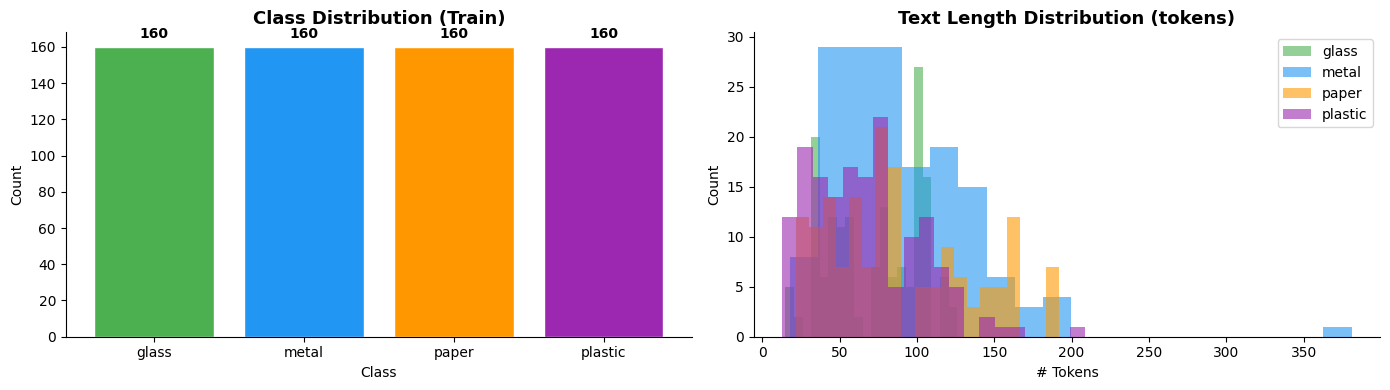

Text length stats:
count    640.00
mean      78.68
std       40.93
min       13.00
25%       47.00
50%       73.00
75%      103.00
max      381.00
Name: text_len, dtype: float64


In [26]:
train_df['text_len'] = train_df['text'].apply(lambda x: len(x.split()))

colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

counts = train_df['label'].value_counts()
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white')
axes[0].bar_label(bars, fmt='%d', padding=4, fontweight='bold')
axes[0].set_title('Class Distribution (Train)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class'); axes[0].set_ylabel('Count')
axes[0].spines[['top','right']].set_visible(False)

for i, label in enumerate(['glass','metal','paper','plastic']):
    axes[1].hist(train_df[train_df['label']==label]['text_len'],
                 bins=20, alpha=0.6, label=label, color=colors[i])
axes[1].set_title('Text Length Distribution (tokens)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('# Tokens'); axes[1].set_ylabel('Count')
axes[1].legend(); axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()
print('Text length stats:')
print(train_df['text_len'].describe().round(2))

##  Encode Labels

In [27]:
le = LabelEncoder()
le.fit(train_df['label'])
NUM_CLASSES = len(le.classes_)

print('Classes:', le.classes_)
print('Mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

Classes: ['glass' 'metal' 'paper' 'plastic']
Mapping: {'glass': np.int64(0), 'metal': np.int64(1), 'paper': np.int64(2), 'plastic': np.int64(3)}


## Tokenization & Padding

In [ ]:
MAX_VOCAB = 5000
MAX_LEN   = 60
EMBED_DIM = 64

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['text'])   

vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)
print(f'Unique words: {len(tokenizer.word_index)}  using top {vocab_size}')

def encode(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_train = encode(train_df['text'])
X_val   = encode(val_df['text'])
X_test  = encode(test_df['text'])

y_train = to_categorical(le.transform(train_df['label']), NUM_CLASSES)
y_val   = to_categorical(le.transform(val_df['label']),   NUM_CLASSES)
y_test  = to_categorical(le.transform(test_df['label']),  NUM_CLASSES)

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}   | y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape}  | y_test:  {y_test.shape}')

Unique words: 6186 → using top 5000
X_train: (640, 60) | y_train: (640, 4)
X_val:   (80, 60)   | y_val:   (80, 4)
X_test:  (80, 60)  | y_test:  (80, 4)


## Build Simple RNN Model

In [29]:
def build_simplernn(vocab_size, embed_dim, max_len, num_classes):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embed_dim,
                  input_length=max_len, name='embedding'),
        SpatialDropout1D(0.2),
        SimpleRNN(128, return_sequences=True, dropout=0.2, name='rnn_1'),
        SimpleRNN(64,  dropout=0.2, name='rnn_2'),
        Dense(64, activation='relu', name='dense_1'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax', name='output'),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_simplernn(vocab_size, EMBED_DIM, MAX_LEN, NUM_CLASSES)
model.summary()

c:\Users\Antoon Younan Nassif\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_1 (SimpleRNN)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_2 (SimpleRNN)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train

In [30]:
early_stop = EarlyStopping(monitor='val_loss', patience=3,
                            restore_best_weights=True, verbose=1)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=2, min_lr=1e-6, verbose=1)

EPOCHS     = 20
BATCH_SIZE = 32

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.3938 - loss: 1.3100 - val_accuracy: 0.5875 - val_loss: 0.9577 - learning_rate: 0.0010
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6687 - loss: 0.8655 - val_accuracy: 0.7625 - val_loss: 0.5965 - learning_rate: 0.0010
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8375 - loss: 0.4876 - val_accuracy: 0.8500 - val_loss: 0.4222 - learning_rate: 0.0010
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9328 - loss: 0.2528 - val_accuracy: 0.8625 - val_loss: 0.2924 - learning_rate: 0.0010
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9719 - loss: 0.1229 - val_accuracy: 0.8250 - val_loss: 0.3964 - learning_rate: 0.0010
Epoch 6/20
17/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9844 - loss: 0.0917
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9797 - loss: 0.0758 - val_accu

## Training Curves

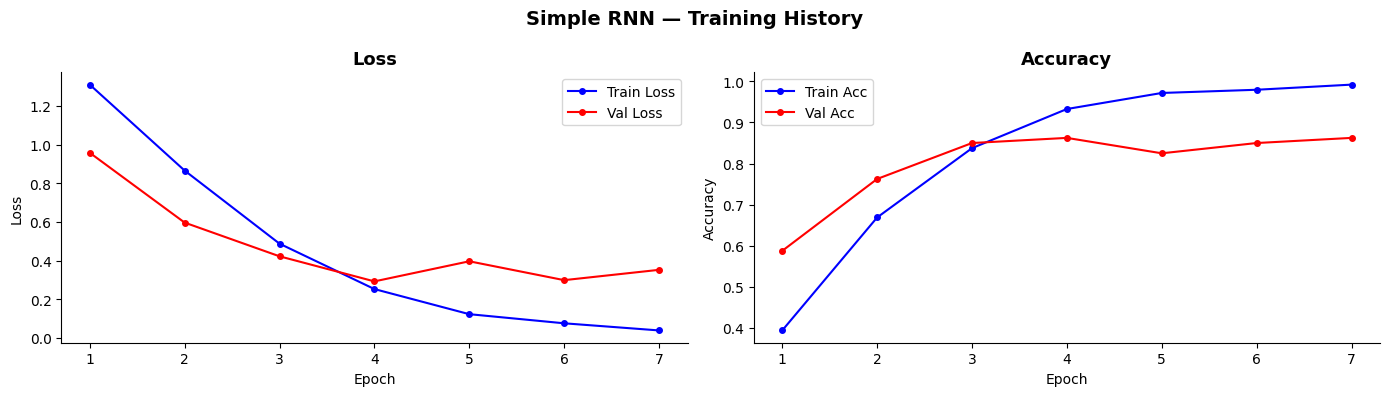

In [31]:
def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    epochs = range(1, len(history.history['loss']) + 1)

    axes[0].plot(epochs, history.history['loss'],     'b-o', ms=4, label='Train Loss')
    axes[0].plot(epochs, history.history['val_loss'], 'r-o', ms=4, label='Val Loss')
    axes[0].set_title('Loss', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)

    axes[1].plot(epochs, history.history['accuracy'],     'b-o', ms=4, label='Train Acc')
    axes[1].plot(epochs, history.history['val_accuracy'], 'r-o', ms=4, label='Val Acc')
    axes[1].set_title('Accuracy', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].spines[['top','right']].set_visible(False)

    plt.suptitle('Simple RNN — Training History', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150)
    plt.show()

plot_history(history)

## Evaluate on Test Set

In [32]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')

Test Loss:     0.3964
Test Accuracy: 0.8250 (82.50%)


Classification Report:
              precision    recall  f1-score   support

       glass       0.87      1.00      0.93        20
       metal       0.71      0.60      0.65        20
       paper       0.95      0.90      0.92        20
     plastic       0.76      0.80      0.78        20

    accuracy                           0.82        80
   macro avg       0.82      0.82      0.82        80
weighted avg       0.82      0.82      0.82        80



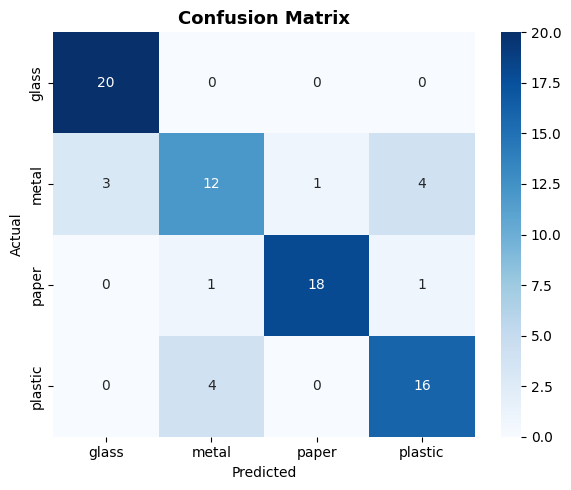

In [33]:
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)

print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## Inference

In [34]:
def predict_text(text, model, tokenizer, le, max_len=MAX_LEN):
    text_clean = clean_text(text)
    seq  = tokenizer.texts_to_sequences([text_clean])
    pad  = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    proba = model.predict(pad, verbose=0)[0]
    pred  = le.classes_[np.argmax(proba)]

    print(f'Input : {text[:80]}')
    print(f'Prediction → {pred.upper()} ({proba.max()*100:.1f}% confidence)')
    print('Class probabilities:')
    for cls, p in sorted(zip(le.classes_, proba), key=lambda x: -x[1]):
        bar = '█' * int(p * 30)
        print(f'  {cls:8s}  {bar:<30s} {p*100:5.1f}%')
    return {'prediction': pred, 'probabilities': dict(zip(le.classes_, proba.tolist()))}

examples = [
    'broken glass bottle recycling silica cullet',
    'crumpled newspaper cardboard paper pulp waste',
    'crushed aluminum steel can metal scrap',
    'plastic polymer polyethylene bottle recycling',
]

for text in examples:
    print('-' * 55)
    predict_text(text, model, tokenizer, le)
    print()

-------------------------------------------------------
Input : broken glass bottle recycling silica cullet
Prediction → METAL (47.6% confidence)
Class probabilities:
  metal     ██████████████                  47.6%
  plastic   █████████                       33.3%
  glass     ████                            15.4%
  paper     █                                3.7%

-------------------------------------------------------
Input : crumpled newspaper cardboard paper pulp waste
Prediction → PLASTIC (50.0% confidence)
Class probabilities:
  plastic   ███████████████                 50.0%
  metal     █████████████                   46.3%
  paper                                      2.6%
  glass                                      1.1%

-------------------------------------------------------
Input : crushed aluminum steel can metal scrap
Prediction → PLASTIC (75.1% confidence)
Class probabilities:
  plastic   ██████████████████████          75.1%
  metal     ████                            15

## Step 11 — Save Model

In [35]:
import pickle

model.save('waste_simplernn_model.h5')
print('Model saved    → waste_simplernn_model.h5')

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print('Tokenizer saved → tokenizer.pkl')

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print('LabelEncoder   → label_encoder.pkl')

Model saved    → waste_simplernn_model.h5
Tokenizer saved → tokenizer.pkl
LabelEncoder   → label_encoder.pkl
